# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Raden Dimas Taufik Rahmat
- **Email:** radendimastaufikrahmat@gmail.com
- **ID Dicoding:** DS704B6Y1459

## Menentukan Pertanyaan Bisnis

Dataset yang dipakai adalah **E-Commerce Public Dataset** (data transaksi marketplace di Brasil). Setiap pertanyaan dirumuskan dengan kerangka **SMART** (Specific, Measurable, Action-Oriented, Relevant, Time-bound). Seluruh analisis dibatasi pada periode **Januari 2017 - Agustus 2018** karena pada 2016 dan September-Oktober 2018 jumlah pesanan hanya puluhan hingga ratusan sehingga tidak representatif.

**Definisi revenue:** dalam proyek ini, revenue didefinisikan sebagai total nilai produk (`price`) dan tidak mencakup biaya pengiriman (`freight_value`).

| Elemen | Pertanyaan 1 | Pertanyaan 2 | Pertanyaan 3 | Pertanyaan 4 |
|---|---|---|---|---|
| **Specific** | Tren pesanan dan revenue bulanan | Kategori produk terbaik | Konsentrasi pelanggan dan kualitas pengiriman per state | Segmentasi pelanggan berdasarkan RFM |
| **Measurable** | Jumlah pesanan, revenue, dan persentase MoM | 5 besar revenue dan jumlah item terjual, serta % kontribusi | Jumlah pelanggan, revenue, rata-rata lama kirim (hari), skor review | Skor Recency, Frequency, Monetary; % pelanggan dan % revenue per segmen |
| **Action-Oriented** | Merencanakan stok dan promosi pada bulan puncak | Memprioritaskan stok dan promosi kategori unggulan | Menentukan wilayah prioritas perbaikan logistik | Menyasar segmen dengan kampanye retensi |
| **Relevant** | Pertumbuhan penjualan | Efisiensi stok dan pemasaran | Kepuasan pelanggan dan biaya logistik | Retensi dan nilai pelanggan jangka panjang |
| **Time-bound** | Jan 2017 - Agu 2018 | Jan 2017 - Agu 2018 | Jan 2017 - Agu 2018 | Jan 2017 - Agu 2018 |

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan dan revenue bulanan (Month-over-Month) selama Januari 2017 - Agustus 2018, dan pada bulan apa jumlah pesanan serta revenue mencapai puncak sehingga tim dapat menyiapkan stok dan promosi pada periode puncak yang sama?
- **Pertanyaan 2:** Kategori produk apa saja yang masuk 5 besar berdasarkan total revenue dan jumlah item terjual selama Januari 2017 - Agustus 2018, dan berapa persen kontribusinya terhadap total revenue, agar stok dan promosi dapat diprioritaskan?
- **Pertanyaan 3:** Di state mana pelanggan dan revenue paling terkonsentrasi, dan state mana yang rata-rata lama pengirimannya di atas rata-rata nasional dengan skor review lebih rendah selama Januari 2017 - Agustus 2018, sehingga perbaikan logistik dapat difokuskan? *(dijawab pada Analisis Lanjutan: geospatial dan binning)*
- **Pertanyaan 4:** Bagaimana segmentasi pelanggan berdasarkan RFM (Recency, Frequency, Monetary) pada periode Januari 2017 - Agustus 2018, dan segmen mana yang menyumbang revenue terbesar serta berisiko hilang sehingga dapat disasar dengan kampanye retensi? *(dijawab pada Analisis Lanjutan: RFM)*

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from branca.colormap import LinearColormap

warnings.filterwarnings("ignore")
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "figure.dpi": 110,
})
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 50

# Palet warna: satu warna sorot (biru), abu-abu untuk pembanding, oranye untuk peringatan
PRIMARY, GRAY, ACCENT = "#2A6F97", "#CBD2D9", "#E07A5F"

DATA_DIR = "data"
OUT_DIR = "dashboard"
os.makedirs(OUT_DIR, exist_ok=True)

## Data Wrangling

### Gathering Data

#### Load df orders, order_items, order_payments, dan order_reviews

In [2]:
orders_df = pd.read_csv(f"{DATA_DIR}/orders_dataset.csv")
items_df = pd.read_csv(f"{DATA_DIR}/order_items_dataset.csv")
payments_df = pd.read_csv(f"{DATA_DIR}/order_payments_dataset.csv")
reviews_df = pd.read_csv(f"{DATA_DIR}/order_reviews_dataset.csv")

for nama, df in [("orders", orders_df), ("order_items", items_df),
                 ("order_payments", payments_df), ("order_reviews", reviews_df)]:
    print(f"{nama:15s} -> {df.shape[0]:>7,} baris, {df.shape[1]} kolom")
orders_df.head()

orders          ->  99,441 baris, 8 kolom
order_items     -> 112,650 baris, 7 kolom
order_payments  -> 103,886 baris, 5 kolom
order_reviews   ->  99,224 baris, 7 kolom


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load df customers, geolocation, dan sellers

In [4]:
customers_df = pd.read_csv(f"{DATA_DIR}/customers_dataset.csv")
geo_df = pd.read_csv(f"{DATA_DIR}/geolocation_dataset.csv")
sellers_df = pd.read_csv(f"{DATA_DIR}/sellers_dataset.csv")

for nama, df in [("customers", customers_df), ("geolocation", geo_df), ("sellers", sellers_df)]:
    print(f"{nama:15s} -> {df.shape[0]:>9,} baris, {df.shape[1]} kolom")
customers_df.head()

customers       ->    99,441 baris, 5 kolom
geolocation     -> 1,000,163 baris, 5 kolom
sellers         ->     3,095 baris, 4 kolom


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
geo_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


#### Load df products dan terjemahan kategori

In [6]:
products_df = pd.read_csv(f"{DATA_DIR}/products_dataset.csv")
category_df = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

for nama, df in [("products", products_df), ("category_translation", category_df)]:
    print(f"{nama:21s} -> {df.shape[0]:>7,} baris, {df.shape[1]} kolom")
products_df.head()

products              ->  32,951 baris, 9 kolom
category_translation  ->      71 baris, 2 kolom


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


**Insight:**
- Terdapat 9 tabel yang saling berhubungan. Kunci penghubung utamanya: `order_id` (orders, items, payments, reviews), `customer_id` (orders - customers), `product_id` (items - products), dan `zip_code_prefix` (customers - geolocation).
- Tabel `orders` berisi 99.441 pesanan, `order_items` 112.650 baris item (satu pesanan bisa berisi beberapa item), dan `geolocation` lebih dari 1 juta baris sehingga perlu diringkas sebelum digabung.
- Kolom tanggal pada `orders` masih terbaca sebagai teks sehingga perlu dikonversi sebelum dipakai menghitung lama pengiriman.

### Assessing Data

#### Identifying missing value

In [7]:
tables = {
    "orders": orders_df, "order_items": items_df, "order_payments": payments_df,
    "order_reviews": reviews_df, "customers": customers_df, "geolocation": geo_df,
    "sellers": sellers_df, "products": products_df, "category_translation": category_df,
}
overview = pd.DataFrame({
    nama: {
        "jumlah_baris": df.shape[0],
        "total_missing": int(df.isna().sum().sum()),
        "baris_duplikat": int(df.duplicated().sum()),
    } for nama, df in tables.items()
}).T
overview

,jumlah_baris,total_missing,baris_duplikat
orders,99441,4908,0
order_items,112650,0,0
order_payments,103886,0,0
order_reviews,99224,145903,0
customers,99441,0,0
geolocation,1000163,0,261831
sellers,3095,0,0
products,32951,2448,0
category_translation,71,0,0


In [8]:
for nama in ["orders", "products", "order_reviews"]:
    miss = tables[nama].isna().sum()
    miss = miss[miss > 0].to_frame("jumlah_missing")
    miss["persen"] = (miss["jumlah_missing"] / len(tables[nama]) * 100).round(2)
    print(f"--- Missing value pada tabel {nama}")
    display(miss)

--- Missing value pada tabel orders


,jumlah_missing,persen
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98


--- Missing value pada tabel products


,jumlah_missing,persen
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


--- Missing value pada tabel order_reviews


,jumlah_missing,persen
review_comment_title,87656,88.34
review_comment_message,58247,58.70


**Steps to Take:**
- `orders`: kolom tanggal tiba (`order_delivered_customer_date`) kosong pada 2.965 pesanan karena belum sampai atau dibatalkan. Fokuskan analisis pada pesanan berstatus `delivered` dan hapus pesanan delivered yang tanggal tibanya tetap kosong.
- `products`: 610 produk tidak memiliki kategori. Isi dengan label `unknown` agar penjualannya tetap terhitung.
- `order_reviews`: kolom judul dan isi komentar kosong sebagian besar, tetapi tidak dibutuhkan. Cukup ambil kolom `review_score`.

#### Identifying invalid data type

In [9]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


**Steps to Take:**
- Seluruh kolom tanggal pada `orders` bertipe teks. Ubah ke `datetime` pada tahap cleaning.

#### Identifying duplicate data

In [10]:
print("Duplikat geolocation :", geo_df.duplicated().sum(), "baris",
      f"({geo_df.duplicated().mean():.1%} dari total)")
print("Zip prefix unik di geolocation:", geo_df["geolocation_zip_code_prefix"].nunique())
print("Duplikat review per order_id   :", reviews_df["order_id"].duplicated().sum(), "baris")

Duplikat geolocation : 261831 baris (26.2% dari total)
Zip prefix unik di geolocation: 19015
Duplikat review per order_id   : 551 baris


**Steps to Take:**
- Hapus 261.831 baris duplikat pada `geolocation`, lalu ringkas menjadi satu titik koordinat (rata-rata) untuk setiap `zip_code_prefix`.
- Ambil hanya review terbaru untuk setiap `order_id` agar satu pesanan hanya memiliki satu skor.

#### Identifying invalid value

In [11]:
# Batas koordinat daratan Brasil (perkiraan): lat -34 s.d. 6, lng -74 s.d. -33
batas_lat, batas_lng = (-34, 6), (-74, -33)
di_luar_brasil = ~(geo_df["geolocation_lat"].between(*batas_lat) & geo_df["geolocation_lng"].between(*batas_lng))
print("Koordinat di luar Brasil:", di_luar_brasil.sum(), "baris")
display(geo_df[di_luar_brasil].head(3))

print("\nPayment_value = 0         :", (payments_df["payment_value"] == 0).sum(), "baris")
print("Payment_type 'not_defined':", (payments_df["payment_type"] == "not_defined").sum(), "baris")
print("Freight_value = 0         :", (items_df["freight_value"] == 0).sum(), "baris")

Koordinat di luar Brasil: 42 baris


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
387565,18243,28.01,-15.54,bom retiro da esperanca,SP
513631,28165,41.61,-8.41,vila nova de campos,RJ
513643,28155,-34.59,-58.73,santa maria,RJ



Payment_value = 0         : 9 baris
Payment_type 'not_defined': 3 baris
Freight_value = 0         : 383 baris


**Steps to Take:**
- Hapus koordinat yang berada di luar wilayah Brasil pada `geolocation` karena tidak mungkin valid.
- Buang pembayaran dengan nilai 0 atau tipe `not_defined`.

#### Identifying inconsistent value

In [12]:
tgl = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
       "order_delivered_customer_date", "order_estimated_delivery_date"]
tmp = orders_df.copy()
tmp[tgl] = tmp[tgl].apply(pd.to_datetime)

print("Distribusi status pesanan:")
display(tmp["order_status"].value_counts().to_frame("jumlah"))

print("Pesanan non-delivered tetapi punya tanggal tiba :",
      ((tmp["order_status"] != "delivered") & tmp["order_delivered_customer_date"].notna()).sum())
print("Pesanan delivered tetapi tanggal tiba kosong    :",
      ((tmp["order_status"] == "delivered") & tmp["order_delivered_customer_date"].isna()).sum())
print("Tanggal tiba lebih awal dari tanggal diserahkan ke kurir:",
      (tmp["order_delivered_customer_date"] < tmp["order_delivered_carrier_date"]).sum())

print("\nKategori produk yang tidak ada di tabel terjemahan:",
      set(products_df["product_category_name"].dropna()) - set(category_df["product_category_name"]))
print("customer_id unik      :", customers_df["customer_id"].nunique())
print("customer_unique_id unik:", customers_df["customer_unique_id"].nunique(),
      "-> satu orang bisa punya beberapa customer_id")
print("Nama kota non-standar (karakter selain huruf/spasi):",
      customers_df["customer_city"].str.contains(r"[^a-z ]", regex=True).sum(), "baris")

Distribusi status pesanan:


,jumlah
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


Pesanan non-delivered tetapi punya tanggal tiba : 6
Pesanan delivered tetapi tanggal tiba kosong    : 8
Tanggal tiba lebih awal dari tanggal diserahkan ke kurir: 23



Kategori produk yang tidak ada di tabel terjemahan: {'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}
customer_id unik      : 99441


customer_unique_id unik: 96096 -> satu orang bisa punya beberapa customer_id


Nama kota non-standar (karakter selain huruf/spasi): 451 baris


**Steps to Take:**
- Ada pesanan yang tanggal tibanya lebih awal daripada tanggal diserahkan ke kurir (data tidak logis). Hapus baris tersebut.
- Dua kategori produk tidak punya terjemahan. Tambahkan terjemahan secara manual.
- Satu pelanggan dapat memiliki beberapa `customer_id`, sehingga perhitungan jumlah pelanggan dan RFM harus memakai `customer_unique_id`.
- Standarkan penulisan nama kota (hapus aksen dan karakter khusus).

#### Identifying outlier

,median,q3,batas_atas_IQR,maks,jumlah_outlier,persen_outlier
price,74.99,134.90,277.40,"6,735.00","8,427.00",7.48
freight_value,16.26,21.15,33.25,409.68,"11,613.00",10.31


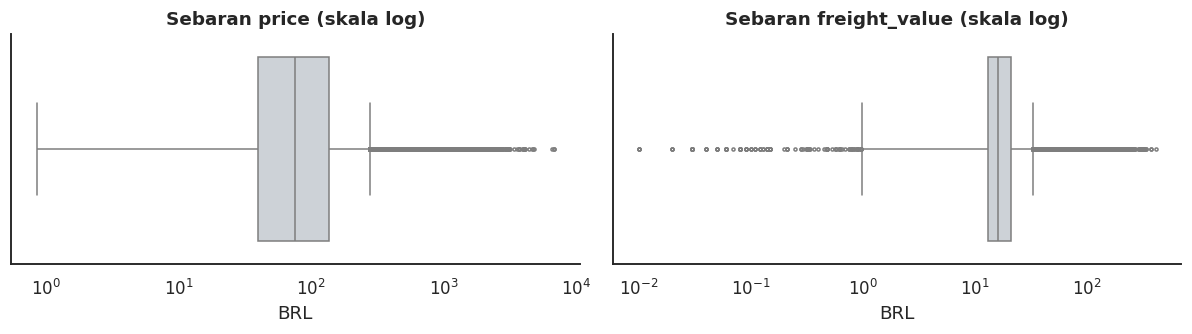

In [13]:
def hitung_outlier(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    batas = q3 + 1.5 * iqr
    return pd.Series({"median": s.median(), "q3": q3, "batas_atas_IQR": batas,
                      "maks": s.max(), "jumlah_outlier": int((s > batas).sum()),
                      "persen_outlier": round((s > batas).mean() * 100, 2)})

display(pd.DataFrame({"price": hitung_outlier(items_df["price"]),
                      "freight_value": hitung_outlier(items_df["freight_value"])}).T)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a, kol in zip(ax, ["price", "freight_value"]):
    sns.boxplot(x=items_df[kol], ax=a, color=GRAY, fliersize=2)
    a.set_xscale("log"); a.set_title(f"Sebaran {kol} (skala log)"); a.set_xlabel("BRL")
plt.tight_layout(); plt.show()

**Steps to Take:**
- Outlier pada `price` dan `freight_value` dipertahankan karena merupakan transaksi yang nyata (misalnya produk bernilai tinggi atau pengiriman ke wilayah terpencil). Pada analisis, gunakan total (revenue) dan jangan menarik kesimpulan dari rata-rata harga saja.

**Insight:**
- Masalah kualitas data yang ditemukan: missing value (`orders`, `products`, `order_reviews`), tipe data tidak sesuai (tanggal), duplikat (`geolocation`, `order_reviews`), nilai tidak valid (koordinat di luar Brasil, pembayaran 0), nilai tidak konsisten (urutan tanggal, nama kategori dan kota), serta outlier (`price` 7,48% dan `freight_value` 10,31% di atas batas IQR).
- Hanya 96.478 dari 99.441 pesanan (97%) berstatus `delivered`, sehingga analisis revenue difokuskan pada pesanan yang benar-benar selesai.

### Cleaning Data

#### Fixing data type problem

In [14]:
kolom_tgl_orders = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
                    "order_delivered_customer_date", "order_estimated_delivery_date"]
orders_df[kolom_tgl_orders] = orders_df[kolom_tgl_orders].apply(pd.to_datetime)
reviews_df["review_answer_timestamp"] = pd.to_datetime(reviews_df["review_answer_timestamp"])
orders_df[kolom_tgl_orders].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

#### Fixing missing value, inconsistent value, dan membatasi periode pada orders

In [15]:
jumlah_awal = len(orders_df)

# 1) Fokus pada pesanan yang selesai (delivered) karena hanya itu yang menghasilkan revenue final
orders_clean = orders_df[orders_df["order_status"] == "delivered"].copy()
print(f"Setelah filter status delivered      : {len(orders_clean):,}")

# 2) Batasi periode analisis penuh: Januari 2017 - Agustus 2018
#    (2016 & Sep-Okt 2018 hanya berisi puluhan s.d. ratusan pesanan -> tidak representatif)
orders_clean = orders_clean[orders_clean["order_purchase_timestamp"].between("2017-01-01", "2018-08-31 23:59:59")]
print(f"Setelah filter periode Jan17-Agu18   : {len(orders_clean):,}")

# 3) Hapus pesanan delivered yang tanggal tibanya kosong (tidak bisa dihitung lama pengirimannya)
orders_clean = orders_clean.dropna(subset=["order_delivered_customer_date"])
print(f"Setelah hapus tanggal tiba kosong    : {len(orders_clean):,}")

# 4) Hapus data tidak konsisten: tiba di pelanggan lebih awal daripada diserahkan ke kurir
tidak_konsisten = orders_clean["order_delivered_customer_date"] < orders_clean["order_delivered_carrier_date"]
orders_clean = orders_clean[~tidak_konsisten]
print(f"Setelah hapus tanggal tidak konsisten: {len(orders_clean):,}")
print(f"\nTotal pesanan dibuang: {jumlah_awal - len(orders_clean):,} ({1 - len(orders_clean)/jumlah_awal:.1%})")

Setelah filter status delivered      : 96,478
Setelah filter periode Jan17-Agu18   : 96,211
Setelah hapus tanggal tiba kosong    : 96,203
Setelah hapus tanggal tidak konsisten: 96,184

Total pesanan dibuang: 3,257 (3.3%)


#### Fixing missing value dan inconsistent value pada kategori produk

In [16]:
# Terjemahkan kategori ke bahasa Inggris; dua kategori yang belum ada diterjemahkan manual
tambahan = pd.DataFrame({
    "product_category_name": ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"],
    "product_category_name_english": ["pc_gamer", "portable_kitchen_food_preparers"],
})
category_full = pd.concat([category_df, tambahan], ignore_index=True)

products_clean = products_df[["product_id", "product_category_name"]].merge(
    category_full, on="product_category_name", how="left")
products_clean["category"] = products_clean["product_category_name_english"].fillna("unknown")
products_clean = products_clean[["product_id", "category"]]

print("Produk tanpa kategori ('unknown'):", (products_clean["category"] == "unknown").sum())
products_clean["category"].nunique()

Produk tanpa kategori ('unknown'): 610


74

#### Fixing duplicate, invalid, dan inconsistent value pada geolocation dan nama kota

In [17]:
# 1) Hapus duplikat  2) Hapus koordinat di luar Brasil  3) Ringkas jadi satu titik (rata-rata) per zip prefix
geo_clean = geo_df.drop_duplicates()
geo_clean = geo_clean[geo_clean["geolocation_lat"].between(*batas_lat) & geo_clean["geolocation_lng"].between(*batas_lng)]
geo_zip = (geo_clean.groupby("geolocation_zip_code_prefix", as_index=False)
           .agg(customer_lat=("geolocation_lat", "mean"), customer_lng=("geolocation_lng", "mean"))
           .rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix"}))

print(f"Baris geolocation: {len(geo_df):,} -> {len(geo_clean):,} setelah dibersihkan")
print(f"Titik koordinat unik (zip prefix): {len(geo_zip):,}")

# Standarisasi nama kota pelanggan (hapus aksen/karakter khusus)
def standarkan_kota(teks):
    teks = unicodedata.normalize("NFKD", str(teks)).encode("ascii", "ignore").decode("ascii")
    teks = re.sub(r"[^A-Za-z ]", " ", teks)          # buang apostrof, tanda hubung, angka, dsb.
    return " ".join(teks.split()).title()

customers_clean = customers_df.copy()
customers_clean["customer_city"] = customers_clean["customer_city"].apply(standarkan_kota)
print("Nama kota non-standar tersisa:", customers_clean["customer_city"].str.contains(r"[^A-Za-z ]", regex=True).sum())

Baris geolocation: 1,000,163 -> 738,299 setelah dibersihkan
Titik koordinat unik (zip prefix): 19,010
Nama kota non-standar tersisa: 0


#### Fixing duplicate dan invalid value pada reviews dan payments

In [18]:
# Satu pesanan hanya boleh punya satu review -> ambil review terbaru
reviews_clean = (reviews_df.sort_values("review_answer_timestamp")
                 .drop_duplicates(subset="order_id", keep="last")[["order_id", "review_score"]])
print("Review duplikat tersisa:", reviews_clean["order_id"].duplicated().sum())

# Pembayaran tidak valid (nilai 0 / tipe not_defined) dibuang
payments_clean = payments_df[(payments_df["payment_value"] > 0) & (payments_df["payment_type"] != "not_defined")]
print(f"Pembayaran: {len(payments_df):,} -> {len(payments_clean):,} baris")

Review duplikat tersisa: 0
Pembayaran: 103,886 -> 103,877 baris


#### Menggabungkan tabel dan membuat kolom turunan

In [19]:
all_df = (items_df
          .merge(orders_clean[["order_id", "customer_id", "order_purchase_timestamp",
                               "order_delivered_customer_date", "order_estimated_delivery_date"]],
                 on="order_id", how="inner")
          .merge(customers_clean[["customer_id", "customer_unique_id", "customer_zip_code_prefix",
                                  "customer_city", "customer_state"]], on="customer_id", how="left")
          .merge(products_clean, on="product_id", how="left")
          .merge(reviews_clean, on="order_id", how="left")
          .merge(geo_zip, on="customer_zip_code_prefix", how="left"))

all_df["category"] = all_df["category"].fillna("unknown")
all_df["revenue"] = all_df["price"]                       # revenue produk (tidak termasuk ongkir)
all_df["order_month"] = all_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
all_df["delivery_days"] = (all_df["order_delivered_customer_date"] - all_df["order_purchase_timestamp"]).dt.total_seconds() / 86400
all_df["is_late"] = all_df["order_delivered_customer_date"] > all_df["order_estimated_delivery_date"]

print("Ukuran data gabungan:", all_df.shape)
print("Missing value tersisa:")
display(all_df.isna().sum()[all_df.isna().sum() > 0].to_frame("missing"))
all_df.head()

Ukuran data gabungan: (109827, 23)
Missing value tersisa:


,missing
review_score,823
customer_lat,289
customer_lng,289


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,category,review_score,customer_lat,customer_lng,revenue,order_month,delivery_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,Campos Dos Goytacazes,RJ,cool_stuff,5.00,-21.76,-41.31,58.90,2017-09,7.61,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,Santa Fe Do Sul,SP,pet_shop,4.00,-20.22,-50.90,239.90,2017-04,16.22,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,Para De Minas,MG,furniture_decor,5.00,-19.87,-44.59,199.00,2018-01,7.95,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,Atibaia,SP,perfumery,4.00,-23.11,-46.59,12.99,2018-08,6.15,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,Varzea Paulista,SP,garden_tools,5.00,-23.24,-46.83,199.90,2017-02,25.11,False


In [20]:
kolom_dashboard = ["order_id", "order_item_id", "customer_unique_id", "customer_state", "customer_city",
                   "customer_lat", "customer_lng", "order_purchase_timestamp", "order_month",
                   "category", "price", "freight_value", "review_score", "delivery_days", "is_late"]
all_df[kolom_dashboard].round({"customer_lat": 3, "customer_lng": 3, "delivery_days": 2}) \
    .to_csv(f"{OUT_DIR}/main_data.csv", index=False)

# Payment untuk pesanan yang dianalisis (dipakai pada EDA metode pembayaran)
payments_final = payments_clean[payments_clean["order_id"].isin(all_df["order_id"])]
print("main_data.csv tersimpan ->", f"{os.path.getsize(f'{OUT_DIR}/main_data.csv')/1e6:.1f} MB")

main_data.csv tersimpan -> 18.3 MB


**Insight:**
- Setelah pembersihan tersisa **96.184 pesanan** (109.827 item) pada periode Januari 2017 - Agustus 2018. Sebanyak 3.257 pesanan (3,3%) dibuang karena belum selesai, di luar periode, atau datanya tidak konsisten.
- Missing value yang tersisa sengaja dibiarkan: `review_score` (823 baris, pesanan belum direview) dan koordinat (289 baris, zip code tidak ada di tabel geolocation). Keduanya otomatis diabaikan pada perhitungan rata-rata.
- Kolom turunan `revenue`, `delivery_days`, `is_late`, dan `order_month` dibuat untuk mendukung analisis. Data gabungan disimpan sebagai `dashboard/main_data.csv` untuk dashboard Streamlit.

## Exploratory Data Analysis (EDA)

### Explore ringkasan data
> **Catatan level analisis:** tabel `all_df` berada pada level *item*. Revenue, harga, dan jumlah item dihitung per item, sedangkan lama pengiriman, keterlambatan, dan skor review adalah atribut *pesanan* sehingga dihitung pada level *order* (`order_level`, satu baris per `order_id`) agar pesanan berisi banyak item tidak terhitung berulang.
>
> **Definisi revenue:** total nilai produk (`price`), tidak termasuk ongkos kirim (`freight_value`).

In [21]:
print("Periode data :", all_df["order_purchase_timestamp"].min().date(), "s.d.", all_df["order_purchase_timestamp"].max().date())
print("Jumlah pesanan  :", f"{all_df['order_id'].nunique():,}")
print("Jumlah item     :", f"{len(all_df):,}")
print("Pelanggan unik  :", f"{all_df['customer_unique_id'].nunique():,}")
print("Total revenue   :", f"R$ {all_df['revenue'].sum():,.0f}")

# Level analisis: harga/ongkir/revenue dihitung per ITEM, sedangkan lama kirim, keterlambatan, dan skor review
# adalah atribut PESANAN, sehingga dihitung per ORDER agar pesanan multi-item tidak terhitung berulang.
order_level = all_df.drop_duplicates("order_id").copy()
print("\nStatistik level item:")
display(all_df[["price", "freight_value"]].describe().T)
print("Statistik level order:")
display(order_level[["review_score", "delivery_days"]].describe().T)

Periode data : 2017-01-05 s.d. 2018-08-29
Jumlah pesanan  : 96,184
Jumlah item     : 109,827
Pelanggan unik  : 93,080
Total revenue   : R$ 13,176,606

Statistik level item:


,count,mean,std,min,25%,50%,75%,max
price,"109,827.00",119.98,182.38,0.85,39.90,74.90,134.17,"6,735.00"
freight_value,"109,827.00",19.95,15.70,0.00,13.08,16.26,21.15,409.68


Statistik level order:


,count,mean,std,min,25%,50%,75%,max
review_score,"95,541.00",4.16,1.28,1.00,4.00,5.00,5.00,5.00
delivery_days,"96,184.00",12.54,9.53,0.53,6.76,10.21,15.68,209.63


### Explore tren pesanan dan revenue bulanan

In [22]:
monthly_df = (all_df.groupby("order_month")
              .agg(order_count=("order_id", "nunique"), revenue=("revenue", "sum"))
              .reset_index())
monthly_df["order_mom_pct"] = monthly_df["order_count"].pct_change() * 100
monthly_df["revenue_mom_pct"] = monthly_df["revenue"].pct_change() * 100
monthly_df["aov"] = monthly_df["revenue"] / monthly_df["order_count"]
monthly_df

,order_month,order_count,revenue,order_mom_pct,revenue_mom_pct,aov
0,2017-01,749,"111,609.71",NaN,NaN,149.01
1,2017-02,1651,"233,832.81",120.43,109.51,141.63
2,2017-03,2545,"359,109.85",54.15,53.58,141.10
3,2017-04,2303,"340,669.68",-9.51,-5.13,147.92
4,2017-05,3544,"488,869.27",53.89,43.50,137.94
5,2017-06,3134,"421,781.48",-11.57,-13.72,134.58
6,2017-07,3861,"480,004.62",23.20,13.80,124.32
7,2017-08,4191,"554,227.91",8.55,15.46,132.24
8,2017-09,4150,"607,399.67",-0.98,9.59,146.36
9,2017-10,4478,"648,247.65",7.90,6.73,144.76


In [23]:
print("Bulan dengan pesanan terbanyak :", monthly_df.loc[monthly_df["order_count"].idxmax(), ["order_month", "order_count"]].tolist())
print("Bulan dengan revenue tertinggi :", monthly_df.loc[monthly_df["revenue"].idxmax(), ["order_month", "revenue"]].tolist())
print("Lonjakan MoM terbesar          :", monthly_df.loc[monthly_df["revenue_mom_pct"].idxmax(), ["order_month", "revenue_mom_pct"]].tolist())

per_tahun = all_df.assign(tahun=all_df["order_purchase_timestamp"].dt.year)
print("\nPerbandingan Jan-Agu 2017 vs Jan-Agu 2018 (periode sama):")
bandingan = (per_tahun[per_tahun["order_purchase_timestamp"].dt.month <= 8]
             .groupby("tahun").agg(pesanan=("order_id", "nunique"), revenue=("revenue", "sum")))
bandingan.loc["pertumbuhan_%"] = (bandingan.loc[2018] / bandingan.loc[2017] - 1) * 100
bandingan

Bulan dengan pesanan terbanyak : ['2017-11', np.int64(7288)]
Bulan dengan revenue tertinggi : ['2017-11', np.float64(987648.07)]
Lonjakan MoM terbesar          : ['2017-02', np.float64(109.50937870907467)]

Perbandingan Jan-Agu 2017 vs Jan-Agu 2018 (periode sama):


,pesanan,revenue
tahun,,
2017,"21,978.00","2,990,105.33"
2018,"52,777.00","7,217,172.24"
pertumbuhan_%,140.14,141.37


### Explore kategori produk

In [24]:
category_df_sum = (all_df.groupby("category")
                   .agg(total_terjual=("order_item_id", "count"), revenue=("revenue", "sum"),
                        harga_rata2=("price", "mean"), skor_review=("review_score", "mean"))
                   .reset_index())
category_df_sum["kontribusi_revenue_%"] = category_df_sum["revenue"] / category_df_sum["revenue"].sum() * 100
print("Jumlah kategori:", len(category_df_sum))
print("\nTop 10 kategori berdasarkan revenue:")
display(category_df_sum.sort_values("revenue", ascending=False).head(10))
print("5 kategori dengan penjualan terendah:")
display(category_df_sum.sort_values("total_terjual").head(5))

Jumlah kategori: 74

Top 10 kategori berdasarkan revenue:


,category,total_terjual,revenue,harga_rata2,skor_review,kontribusi_revenue_%
43,health_beauty,9420,"1,229,425.70",130.51,4.19,9.33
73,watches_gifts,5852,"1,163,121.02",198.76,4.07,8.83
7,bed_bath_table,10941,"1,022,541.17",93.46,3.92,7.76
67,sports_leisure,8411,"952,476.41",113.24,4.17,7.23
15,computers_accessories,7629,"887,761.73",116.37,3.99,6.74
39,furniture_decor,8086,"705,756.22",87.28,3.96,5.36
49,housewares,6774,"614,143.12",90.66,4.11,4.66
20,cool_stuff,3710,"609,070.01",164.17,4.20,4.62
5,auto,4130,"577,695.10",139.88,4.12,4.38
42,garden_tools,4261,"468,853.41",110.03,4.08,3.56


5 kategori dengan penjualan terendah:


,category,total_terjual,revenue,harga_rata2,skor_review,kontribusi_revenue_%
63,security_and_services,2,283.29,141.64,2.50,0.00
29,fashion_childrens_clothes,7,519.95,74.28,5.00,0.00
59,pc_gamer,8,"1,306.95",163.37,3.62,0.01
11,cds_dvds_musicals,14,730.00,52.14,4.64,0.01
52,la_cuisine,14,"2,054.99",146.78,4.00,0.02


In [25]:
top5_rev = category_df_sum.nlargest(5, "revenue")
print(f"Top 5 kategori (revenue) menyumbang {top5_rev['kontribusi_revenue_%'].sum():.1f}% dari total revenue")
top10_rev = category_df_sum.nlargest(10, "revenue")
print(f"Top 10 kategori (revenue) menyumbang {top10_rev['kontribusi_revenue_%'].sum():.1f}% dari total revenue")

Top 5 kategori (revenue) menyumbang 39.9% dari total revenue
Top 10 kategori (revenue) menyumbang 62.5% dari total revenue


### Explore state pelanggan

In [26]:
# Pelanggan dan revenue dihitung dari level item; lama kirim, keterlambatan, dan review dari level order
state_item = (all_df.groupby("customer_state")
              .agg(customer_count=("customer_unique_id", "nunique"), revenue=("revenue", "sum"),
                   lat=("customer_lat", "mean"), lng=("customer_lng", "mean")))
state_order = (order_level.groupby("customer_state")
               .agg(order_count=("order_id", "count"), avg_delivery_days=("delivery_days", "mean"),
                    late_pct=("is_late", "mean"), avg_review=("review_score", "mean")))
state_df = state_item.join(state_order).reset_index()
state_df["late_pct"] *= 100
state_df["customer_share_%"] = state_df["customer_count"] / state_df["customer_count"].sum() * 100
state_df = state_df.sort_values("customer_count", ascending=False).reset_index(drop=True)
state_df.head(10)

,customer_state,customer_count,revenue,lat,lng,order_count,avg_delivery_days,late_pct,avg_review,customer_share_%
0,SP,39048,"5,052,686.23",-23.17,-47.05,40387,8.74,5.90,4.25,41.93
1,RJ,11879,"1,751,433.85",-22.76,-43.18,12310,15.30,13.52,3.97,12.76
2,MG,10965,"1,547,473.30",-19.92,-44.43,11315,11.99,5.63,4.19,11.78
3,RS,5149,"726,037.92",-29.71,-51.96,5326,15.29,7.17,4.19,5.53
4,PR,4750,"664,048.00",-24.81,-50.79,4903,11.97,5.02,4.24,5.10
5,SC,3439,"504,323.57",-27.25,-49.57,3535,14.95,9.79,4.13,3.69
6,BA,3155,"493,339.26",-13.03,-39.48,3253,19.33,14.05,3.93,3.39
7,DF,2013,"295,454.64",-15.81,-47.98,2074,12.94,7.09,4.13,2.16
8,ES,1925,"267,783.66",-20.16,-40.48,1992,15.78,12.25,4.08,2.07
9,GO,1889,"281,932.21",-16.61,-49.33,1950,15.61,8.21,4.10,2.03


In [27]:
print(f"3 state teratas (SP, RJ, MG) = {state_df.head(3)['customer_share_%'].sum():.1f}% dari seluruh pelanggan")
print(f"SP sendiri = {state_df.loc[state_df['customer_state']=='SP','customer_share_%'].iloc[0]:.1f}%")
print("\nState dengan pengiriman TERLAMA (min. 200 pesanan):")
display(state_df[state_df["order_count"] >= 200].nlargest(5, "avg_delivery_days")
        [["customer_state", "order_count", "avg_delivery_days", "late_pct", "avg_review"]])
print("State dengan pengiriman TERCEPAT (min. 200 pesanan):")
display(state_df[state_df["order_count"] >= 200].nsmallest(5, "avg_delivery_days")
        [["customer_state", "order_count", "avg_delivery_days", "late_pct", "avg_review"]])

3 state teratas (SP, RJ, MG) = 66.5% dari seluruh pelanggan
SP sendiri = 41.9%

State dengan pengiriman TERLAMA (min. 200 pesanan):


,customer_state,order_count,avg_delivery_days,late_pct,avg_review
19,AL,396,24.52,23.99,3.85
12,PA,942,23.76,12.42,3.91
14,MA,713,21.54,19.64,3.83
20,SE,332,21.44,15.36,3.90
11,CE,1273,21.24,15.40,3.94


State dengan pengiriman TERCEPAT (min. 200 pesanan):


,customer_state,order_count,avg_delivery_days,late_pct,avg_review
0,SP,40387,8.74,5.90,4.25
4,PR,4903,11.97,5.02,4.24
2,MG,11315,11.99,5.63,4.19
7,DF,2074,12.94,7.09,4.13
5,SC,3535,14.95,9.79,4.13


### Explore hubungan ketepatan pengiriman dan skor review

In [28]:
review_by_late = order_level.groupby("is_late").agg(
    pesanan=("order_id", "count"), skor_review=("review_score", "mean"),
    lama_kirim=("delivery_days", "mean"))
review_by_late.index = review_by_late.index.map({False: "Tepat waktu", True: "Terlambat"})
print("Perbandingan pesanan tepat waktu vs terlambat:")
display(review_by_late)

print("Korelasi lama pengiriman vs skor review:",
      round(order_level[["delivery_days", "review_score"]].corr().iloc[0, 1], 3))

Perbandingan pesanan tepat waktu vs terlambat:


,pesanan,skor_review,lama_kirim
is_late,,,
Tepat waktu,88362,4.30,10.86
Terlambat,7822,2.57,31.50


Korelasi lama pengiriman vs skor review: -0.335


### Explore metode pembayaran

In [29]:
pay_df = (payments_final.groupby("payment_type")
          .agg(jumlah_transaksi=("order_id", "count"), nilai_total=("payment_value", "sum"),
               cicilan_rata2=("payment_installments", "mean")).reset_index())
pay_df["persen_transaksi"] = pay_df["jumlah_transaksi"] / pay_df["jumlah_transaksi"].sum() * 100
pay_df.sort_values("jumlah_transaksi", ascending=False)

,payment_type,jumlah_transaksi,nilai_total,cicilan_rata2,persen_transaksi
1,credit_card,74353,"12,059,157.82",3.50,74.03
0,boleto,19137,"2,761,635.32",1.00,19.05
3,voucher,5466,"342,000.35",1.00,5.44
2,debit_card,1483,"207,825.15",1.00,1.48


**Insight:**
- Total revenue produk selama periode analisis mencapai **R$ 13,18 juta** dari 96.184 pesanan dan 93.080 pelanggan unik.
- Revenue dan pesanan tertinggi terjadi pada **November 2017** (7.288 pesanan, R$ 987.648), naik 62,8% (pesanan) dan 52,4% (revenue) dibanding Oktober 2017. Rata-rata nilai pesanan relatif stabil di kisaran R$ 124 - R$ 149, sehingga pertumbuhan terutama berasal dari bertambahnya jumlah pesanan, bukan kenaikan nilai per pesanan.
- Pada periode yang sama (Jan - Agu), pesanan 2018 tumbuh **140,1%** dan revenue **141,4%** dibanding 2017.
- Lima kategori teratas menyumbang **39,9%** revenue dan sepuluh kategori teratas **62,5%** dari total 74 kategori.
- Tiga state (SP, RJ, MG) menyumbang **66,5%** pelanggan; SP sendiri 41,9%. Pengiriman ke SP rata-rata 8,7 hari, sedangkan ke AL 24,5 hari.
- Pesanan yang terlambat (7.822 pesanan, sekitar 8,1%) mendapat skor review rata-rata **2,57** dibandingkan **4,30** untuk pesanan tepat waktu.
- Kartu kredit dipakai pada 74% transaksi dengan rata-rata 3,5 cicilan, diikuti boleto 19%.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan revenue bulanan (MoM) selama Januari 2017 - Agustus 2018, dan kapan puncaknya terjadi?

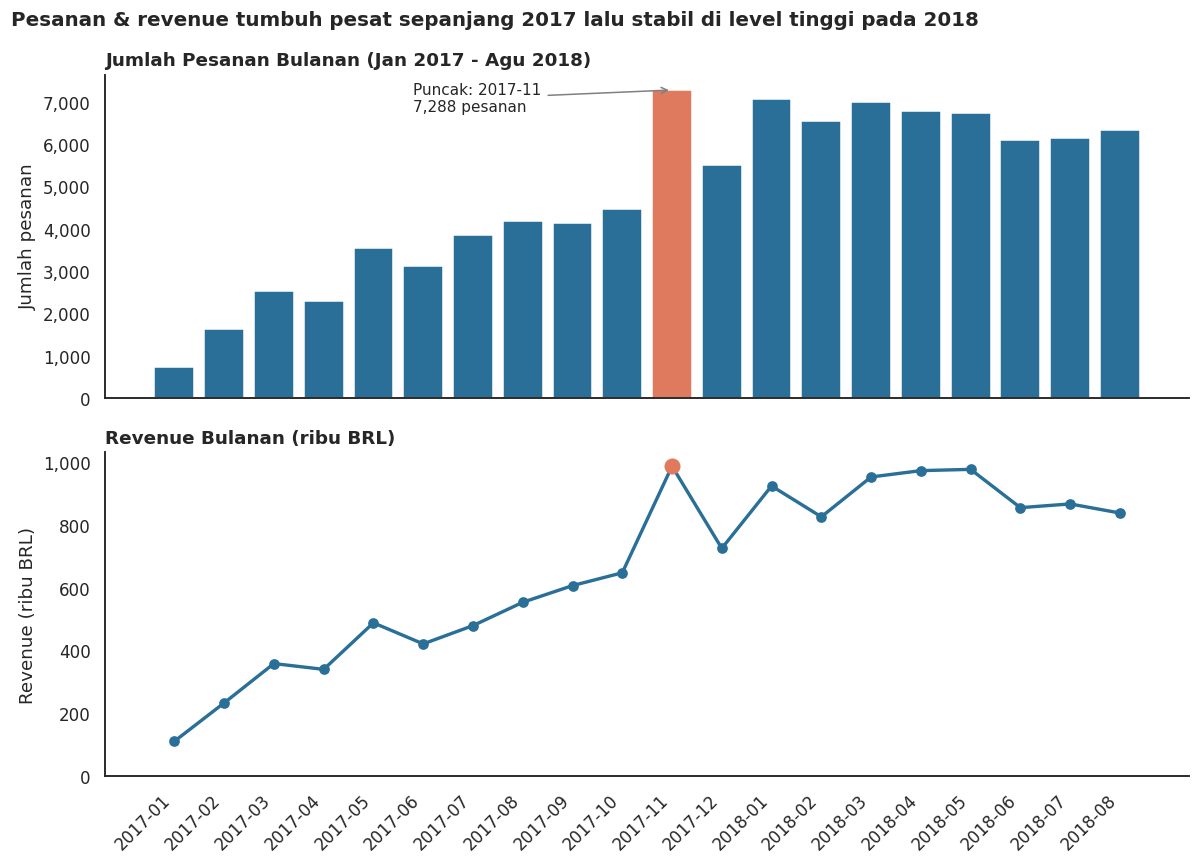

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
x = np.arange(len(monthly_df))
puncak = monthly_df["order_count"].idxmax()

# Panel atas: jumlah pesanan (bar, bulan puncak disorot)
warna = [ACCENT if i == puncak else PRIMARY for i in range(len(monthly_df))]
ax[0].bar(x, monthly_df["order_count"], color=warna)
ax[0].set_title("Jumlah Pesanan Bulanan (Jan 2017 - Agu 2018)", loc="left")
ax[0].set_ylabel("Jumlah pesanan")
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax[0].annotate(f"Puncak: {monthly_df.loc[puncak,'order_month']}\n{monthly_df.loc[puncak,'order_count']:,} pesanan",
               xy=(puncak, monthly_df.loc[puncak, "order_count"]), xytext=(puncak - 5.2, monthly_df["order_count"].max() * 0.93),
               arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)

# Panel bawah: revenue (line)
ax[1].plot(x, monthly_df["revenue"] / 1e3, color=PRIMARY, marker="o", linewidth=2.2)
ax[1].scatter(puncak, monthly_df.loc[puncak, "revenue"] / 1e3, color=ACCENT, s=90, zorder=3)
ax[1].set_title("Revenue Bulanan (ribu BRL)", loc="left")
ax[1].set_ylabel("Revenue (ribu BRL)")
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax[1].set_xticks(x); ax[1].set_xticklabels(monthly_df["order_month"], rotation=45, ha="right")
ax[1].set_ylim(bottom=0)
fig.suptitle("Pesanan & revenue tumbuh pesat sepanjang 2017 lalu stabil di level tinggi pada 2018", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Insight Pertanyaan 1:**
- Pesanan naik dari 749 (Januari 2017) menjadi 4.478 (Oktober 2017), lalu mencapai puncak **7.288 pesanan pada November 2017** (naik 62,8% dari Oktober). Data tidak memuat informasi kampanye atau promosi, sehingga penyebab spesifik kenaikan tersebut tidak dapat ditentukan dari dataset.
- Pertumbuhan MoM terbesar sebenarnya terjadi pada Februari 2017 (+120,4% pesanan, +109,5% revenue), tetapi dari basis yang sangat kecil (749 pesanan pada Januari). November 2017 adalah puncak dalam angka absolut, bukan bulan dengan pertumbuhan MoM tertinggi.
- Setelah puncak, Desember 2017 turun 24,4% (pesanan) dan 26,5% (revenue), lalu pada 2018 penjualan stabil di kisaran 6.000 - 7.100 pesanan dan R$ 826 ribu - R$ 978 ribu per bulan.
- Revenue tertinggi pada 2018 tercapai pada Mei (R$ 977.545), sedangkan Juni - Agustus 2018 turun sekitar 12% dari Mei lalu relatif datar. Pertumbuhan 2018 cenderung melandai dibanding 2017.

### Pertanyaan 2: Kategori produk apa saja yang masuk 5 besar berdasarkan revenue dan jumlah item terjual, dan berapa kontribusinya?

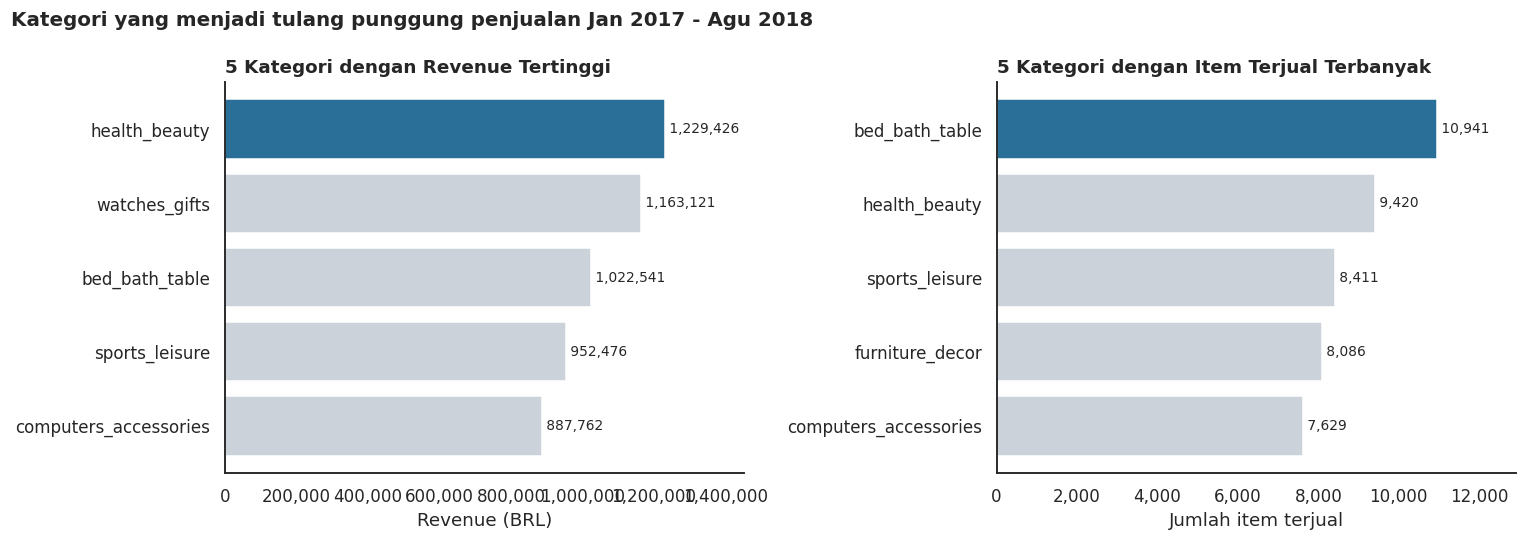

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top_rev = category_df_sum.nlargest(5, "revenue").sort_values("revenue")
top_qty = category_df_sum.nlargest(5, "total_terjual").sort_values("total_terjual")

for a, data, kol, judul, satuan in [
    (ax[0], top_rev, "revenue", "5 Kategori dengan Revenue Tertinggi", "Revenue (BRL)"),
    (ax[1], top_qty, "total_terjual", "5 Kategori dengan Item Terjual Terbanyak", "Jumlah item terjual")]:
    warna = [GRAY] * 4 + [PRIMARY]                       # hanya peringkat 1 yang disorot
    bars = a.barh(data["category"], data[kol], color=warna)
    a.set_title(judul, loc="left"); a.set_xlabel(satuan); a.set_ylabel("")
    a.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    for b in bars:
        a.text(b.get_width(), b.get_y() + b.get_height() / 2, f" {b.get_width():,.0f}", va="center", fontsize=9)
    a.set_xlim(0, data[kol].max() * 1.18)
fig.suptitle("Kategori yang menjadi tulang punggung penjualan Jan 2017 - Agu 2018", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [32]:
# Pembanding: kategori terlaris menurut jumlah vs revenue tidak selalu sama -> lihat harga rata-rata
bandingkan = category_df_sum[category_df_sum["category"].isin(set(top_rev["category"]) | set(top_qty["category"]))]
bandingkan.sort_values("revenue", ascending=False)[["category", "total_terjual", "revenue", "harga_rata2", "skor_review"]]

,category,total_terjual,revenue,harga_rata2,skor_review
43,health_beauty,9420,"1,229,425.70",130.51,4.19
73,watches_gifts,5852,"1,163,121.02",198.76,4.07
7,bed_bath_table,10941,"1,022,541.17",93.46,3.92
67,sports_leisure,8411,"952,476.41",113.24,4.17
15,computers_accessories,7629,"887,761.73",116.37,3.99
39,furniture_decor,8086,"705,756.22",87.28,3.96


**Insight Pertanyaan 2:**
- 5 kategori dengan revenue tertinggi: `health_beauty` (R$ 1,23 juta; 9,3%), `watches_gifts` (R$ 1,16 juta; 8,8%), `bed_bath_table` (R$ 1,02 juta; 7,8%), `sports_leisure` (R$ 952 ribu; 7,2%), dan `computers_accessories` (R$ 888 ribu; 6,7%). Kelimanya menyumbang **39,9%** total revenue.
- Peringkat revenue dan jumlah terjual tidak sama. `bed_bath_table` paling banyak terjual (10.941 item) tetapi harga rata-rata hanya R$ 93 dengan skor review 3,92 (terendah di antara kategori teratas). Sebaliknya `watches_gifts` hanya terjual 5.852 item namun harga rata-rata R$ 199 sehingga revenue menempati urutan kedua.
- Dari 74 kategori, penjualannya sangat timpang: beberapa kategori hanya terjual kurang dari 10 item selama periode ini (misalnya `security_and_services` hanya 2 item).

## Analisis Lanjutan

Pada bagian ini diterapkan tiga teknik analisis lanjutan **tanpa algoritma machine learning**:

1. **Geospatial Analysis** - menganalisis data berdasarkan lokasi geografis untuk menemukan pola wilayah. Tujuannya melihat di mana pelanggan terkonsentrasi dan wilayah mana yang pengirimannya lambat. Titik koordinat tiap state diperoleh dari rata-rata koordinat pelanggan (tabel geolocation yang sudah dibersihkan), lalu divisualisasikan pada peta statis (matplotlib) dan peta interaktif (folium).
2. **Binning (Manual Grouping)** - membagi lama pengiriman ke dalam rentang hari (0-7, 8-14, 15-21, 22-30, >30) untuk melihat pada titik mana kepuasan pelanggan turun tajam.
3. **RFM Analysis** - mengelompokkan pelanggan berdasarkan *Recency* (hari sejak pembelian terakhir), *Frequency* (jumlah pesanan), dan *Monetary* (total belanja). Skor Recency dan Monetary dibuat dengan kuintil (1-5), sedangkan Frequency dibagi manual (1, 2, 3+ pesanan) karena sekitar 97% pelanggan hanya membeli satu kali. Pelanggan diidentifikasi dengan `customer_unique_id`, lalu dikelompokkan dengan aturan bisnis menjadi enam segmen.

### Pertanyaan 3: Di state mana pelanggan terkonsentrasi dan state mana yang pengirimannya lambat dengan skor review lebih rendah? (Geospatial dan Binning)

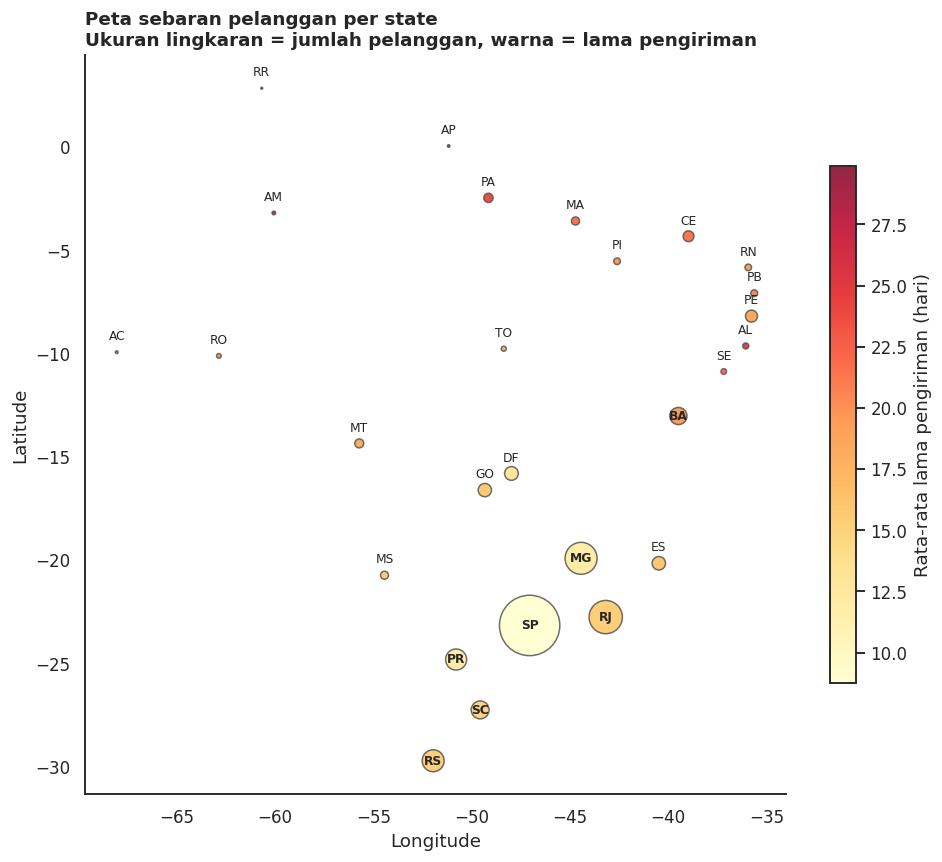

In [33]:
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(state_df["lng"], state_df["lat"], s=state_df["customer_count"] / 25,
                c=state_df["avg_delivery_days"], cmap="YlOrRd", edgecolor="#555", alpha=0.85)
for _, r in state_df.iterrows():
    besar = r["customer_count"] > 3000
    ax.annotate(r["customer_state"], (r["lng"], r["lat"]), ha="center", va="center" if besar else "bottom",
                xytext=(0, 0 if besar else 6), textcoords="offset points", fontsize=8,
                fontweight="bold" if besar else "normal")
cb = plt.colorbar(sc, ax=ax, shrink=0.7); cb.set_label("Rata-rata lama pengiriman (hari)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Peta sebaran pelanggan per state\nUkuran lingkaran = jumlah pelanggan, warna = lama pengiriman", loc="left")
plt.tight_layout(); plt.show()

In [34]:
peta = folium.Map(location=[-15.0, -52.0], zoom_start=4, tiles="CartoDB positron")
cmap = LinearColormap(["#fee08b", "#f46d43", "#a50026"], vmin=state_df["avg_delivery_days"].min(),
                      vmax=state_df["avg_delivery_days"].max(), caption="Rata-rata lama pengiriman (hari)")
for _, r in state_df.iterrows():
    folium.CircleMarker(
        location=[r["lat"], r["lng"]], radius=4 + (r["customer_count"] ** 0.5) / 6,
        color="#333", weight=1, fill=True, fill_color=cmap(r["avg_delivery_days"]), fill_opacity=0.8,
        tooltip=(f"<b>{r['customer_state']}</b><br>Pelanggan: {r['customer_count']:,}<br>Revenue: R$ {r['revenue']:,.0f}"
                 f"<br>Lama kirim: {r['avg_delivery_days']:.1f} hari<br>Review: {r['avg_review']:.2f}"),
    ).add_to(peta)
cmap.add_to(peta)
peta.save(f"{OUT_DIR}/peta_pelanggan.html")   # salinan untuk dibuka di browser
peta

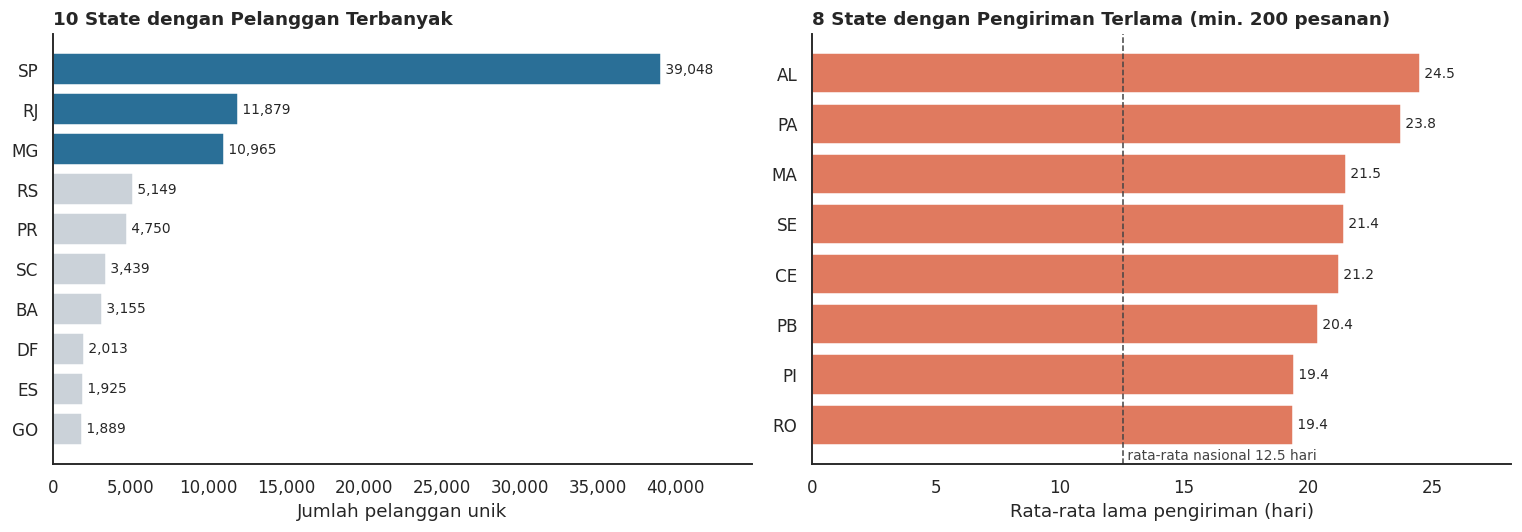

In [35]:
top10 = state_df.head(10).sort_values("customer_count")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
bars = ax[0].barh(top10["customer_state"], top10["customer_count"], color=[GRAY] * 7 + [PRIMARY] * 3)
ax[0].set_title("10 State dengan Pelanggan Terbanyak", loc="left"); ax[0].set_xlabel("Jumlah pelanggan unik")
ax[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
for b in bars:
    ax[0].text(b.get_width(), b.get_y() + b.get_height() / 2, f" {b.get_width():,.0f}", va="center", fontsize=9)
ax[0].set_xlim(0, top10["customer_count"].max() * 1.15)

lambat = state_df[state_df["order_count"] >= 200].nlargest(8, "avg_delivery_days").sort_values("avg_delivery_days")
nasional = order_level["delivery_days"].mean()
bars = ax[1].barh(lambat["customer_state"], lambat["avg_delivery_days"], color=ACCENT)
ax[1].axvline(nasional, color="#444", linestyle="--", linewidth=1)
ax[1].text(nasional, -0.7, f" rata-rata nasional {nasional:.1f} hari", fontsize=9, color="#444")
ax[1].set_title("8 State dengan Pengiriman Terlama (min. 200 pesanan)", loc="left"); ax[1].set_xlabel("Rata-rata lama pengiriman (hari)")
for b in bars:
    ax[1].text(b.get_width(), b.get_y() + b.get_height() / 2, f" {b.get_width():.1f}", va="center", fontsize=9)
ax[1].set_xlim(0, lambat["avg_delivery_days"].max() * 1.15)
plt.tight_layout(); plt.show()

#### Binning lama pengiriman terhadap skor review

In [36]:
# Binning manual: kelompokkan lama pengiriman ke dalam rentang hari
bins = [0, 7, 14, 21, 30, np.inf]
labels = ["0-7 hari", "8-14 hari", "15-21 hari", "22-30 hari", ">30 hari"]
order_level["delivery_bin"] = pd.cut(order_level["delivery_days"], bins=bins, labels=labels)

bin_df = (order_level.groupby("delivery_bin", observed=True)
          .agg(jumlah_pesanan=("order_id", "count"), skor_review=("review_score", "mean"),
               persen_bintang_1_2=("review_score", lambda s: (s <= 2).mean() * 100))
          .reset_index())
bin_df["persen_pesanan"] = bin_df["jumlah_pesanan"] / bin_df["jumlah_pesanan"].sum() * 100
bin_df

,delivery_bin,jumlah_pesanan,skor_review,persen_bintang_1_2,persen_pesanan
0,0-7 hari,26022,4.42,7.39,27.05
1,8-14 hari,40109,4.31,8.90,41.70
2,15-21 hari,17652,4.14,11.59,18.35
3,22-30 hari,7899,3.61,24.09,8.21
4,>30 hari,4502,2.24,61.66,4.68


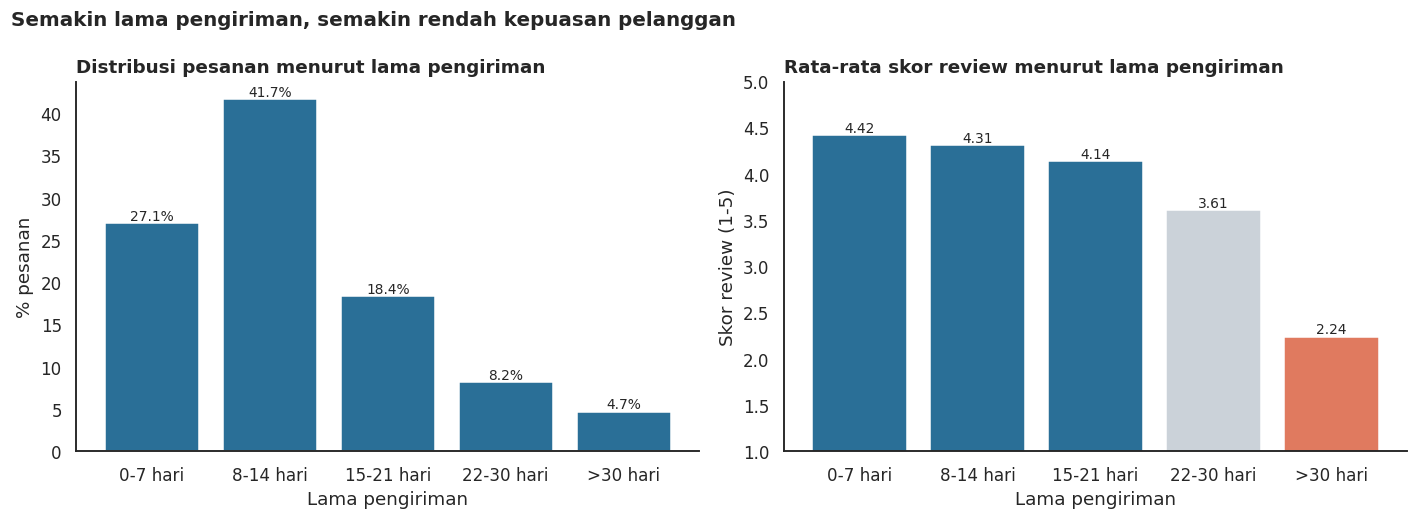

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
w = [PRIMARY, PRIMARY, GRAY, GRAY, ACCENT]
bars = ax[0].bar(bin_df["delivery_bin"].astype(str), bin_df["persen_pesanan"], color=PRIMARY)
ax[0].set_title("Distribusi pesanan menurut lama pengiriman", loc="left"); ax[0].set_ylabel("% pesanan"); ax[0].set_xlabel("Lama pengiriman")
for b in bars:
    ax[0].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

warna = [PRIMARY if s >= 4 else (GRAY if s >= 3.5 else ACCENT) for s in bin_df["skor_review"]]
bars = ax[1].bar(bin_df["delivery_bin"].astype(str), bin_df["skor_review"], color=warna)
ax[1].set_ylim(1, 5); ax[1].set_title("Rata-rata skor review menurut lama pengiriman", loc="left")
ax[1].set_ylabel("Skor review (1-5)"); ax[1].set_xlabel("Lama pengiriman")
for b in bars:
    ax[1].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Semakin lama pengiriman, semakin rendah kepuasan pelanggan", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Insight Pertanyaan 3:**
- Pelanggan sangat terkonsentrasi di Tenggara Brasil: **SP (41,9%), RJ (12,8%), dan MG (11,8%)** = 66,5% pelanggan. SP juga menyumbang sekitar 38% revenue (R$ 5,05 juta) dengan pengiriman tercepat (8,7 hari), keterlambatan 5,9%, dan skor review 4,25.
- State di Timur Laut dan Utara memiliki pengiriman paling lama: AL (24,5 hari; 24,0% terlambat), PA (23,8 hari), MA (21,5 hari; 19,6% terlambat), SE (21,4 hari), dan CE (21,2 hari), jauh di atas rata-rata nasional 12,5 hari.
- Pasar besar yang perlu perhatian: **RJ** (15,3 hari; 13,5% terlambat; review 3,97) dan **BA** (19,3 hari; 14,1% terlambat; review 3,93), karena volumenya besar tetapi kualitas pengirimannya di bawah SP.
- Hasil binning: skor review turun dari 4,42 (0-7 hari) menjadi 4,14 (15-21 hari), lalu anjlok ke **3,61 (22-30 hari)** dan **2,24 (>30 hari)**. Pada pesanan >30 hari, 61,7% mendapat bintang 1-2. Sekitar 12,9% pesanan membutuhkan lebih dari 21 hari.

### Pertanyaan 4: Bagaimana segmentasi pelanggan berdasarkan RFM, dan segmen mana yang menyumbang revenue terbesar serta berisiko hilang? (RFM Analysis)

In [38]:
# Titik acuan: 1 hari setelah transaksi terakhir pada data
snapshot = all_df["order_purchase_timestamp"].max().normalize() + pd.Timedelta(days=1)

rfm_df = (all_df.groupby("customer_unique_id")
          .agg(last_purchase=("order_purchase_timestamp", "max"),
               frequency=("order_id", "nunique"), monetary=("revenue", "sum"))
          .reset_index())
rfm_df["recency"] = (snapshot - rfm_df["last_purchase"].dt.normalize()).dt.days

print("Pelanggan unik:", f"{len(rfm_df):,}")
print(f"Pelanggan yang hanya membeli 1 kali: {(rfm_df['frequency']==1).mean():.1%}")
rfm_df[["recency", "frequency", "monetary"]].describe().T

Pelanggan unik: 93,080
Pelanggan yang hanya membeli 1 kali: 97.0%


,count,mean,std,min,25%,50%,75%,max
recency,"93,080.00",237.21,150.93,1.00,115.00,219.00,346.00,602.00
frequency,"93,080.00",1.03,0.21,1.00,1.00,1.00,1.00,15.00
monetary,"93,080.00",141.56,215.78,0.85,47.65,89.70,154.00,"13,440.00"


In [39]:
# Recency & Monetary -> skor 1-5 (kuintil). Frequency -> binning manual karena hampir semua pelanggan hanya membeli 1x
rfm_df["r_score"] = pd.qcut(rfm_df["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df["m_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df["f_score"] = pd.cut(rfm_df["frequency"], bins=[0, 1, 2, np.inf], labels=[1, 2, 3]).astype(int)

kondisi = [
    rfm_df["f_score"] >= 2,
    (rfm_df["r_score"] >= 4) & (rfm_df["m_score"] >= 4),
    rfm_df["r_score"] >= 4,
    (rfm_df["r_score"] <= 2) & (rfm_df["m_score"] >= 4),
    rfm_df["r_score"] <= 2,
]
nama_segmen = ["Repeat Customers", "Recent Big Spenders", "Recent Buyers", "At-Risk Big Spenders", "Hibernating"]
rfm_df["segment"] = np.select(kondisi, nama_segmen, default="Need Attention")

segmen_df = (rfm_df.groupby("segment")
             .agg(jumlah_pelanggan=("customer_unique_id", "count"), recency_rata2=("recency", "mean"),
                  monetary_rata2=("monetary", "mean"), total_monetary=("monetary", "sum"))
             .reset_index())
segmen_df["persen_pelanggan"] = segmen_df["jumlah_pelanggan"] / segmen_df["jumlah_pelanggan"].sum() * 100
segmen_df["persen_revenue"] = segmen_df["total_monetary"] / segmen_df["total_monetary"].sum() * 100
display(segmen_df.sort_values("persen_revenue", ascending=False))

at_risk = rfm_df[rfm_df["segment"] == "At-Risk Big Spenders"]
print(f"At-Risk Big Spenders: {len(at_risk):,} pelanggan, recency rata-rata {at_risk['recency'].mean():.0f} hari, "
      f"{(at_risk['recency'] > 365).mean():.1%} di antaranya lebih dari 365 hari tidak bertransaksi")

,segment,jumlah_pelanggan,recency_rata2,monetary_rata2,total_monetary,persen_pelanggan,persen_revenue
3,Recent Big Spenders,14439,91.96,267.09,"3,856,581.29",15.51,29.27
0,At-Risk Big Spenders,13745,392.19,276.39,"3,799,031.80",14.77,28.83
2,Need Attention,18016,219.81,130.10,"2,343,909.06",19.36,17.79
1,Hibernating,22498,393.26,55.74,"1,253,940.25",24.17,9.52
4,Recent Buyers,21596,89.89,55.51,"1,198,807.54",23.20,9.10
5,Repeat Customers,2786,219.86,259.99,"724,336.21",2.99,5.50


At-Risk Big Spenders: 13,745 pelanggan, recency rata-rata 392 hari, 54.3% di antaranya lebih dari 365 hari tidak bertransaksi


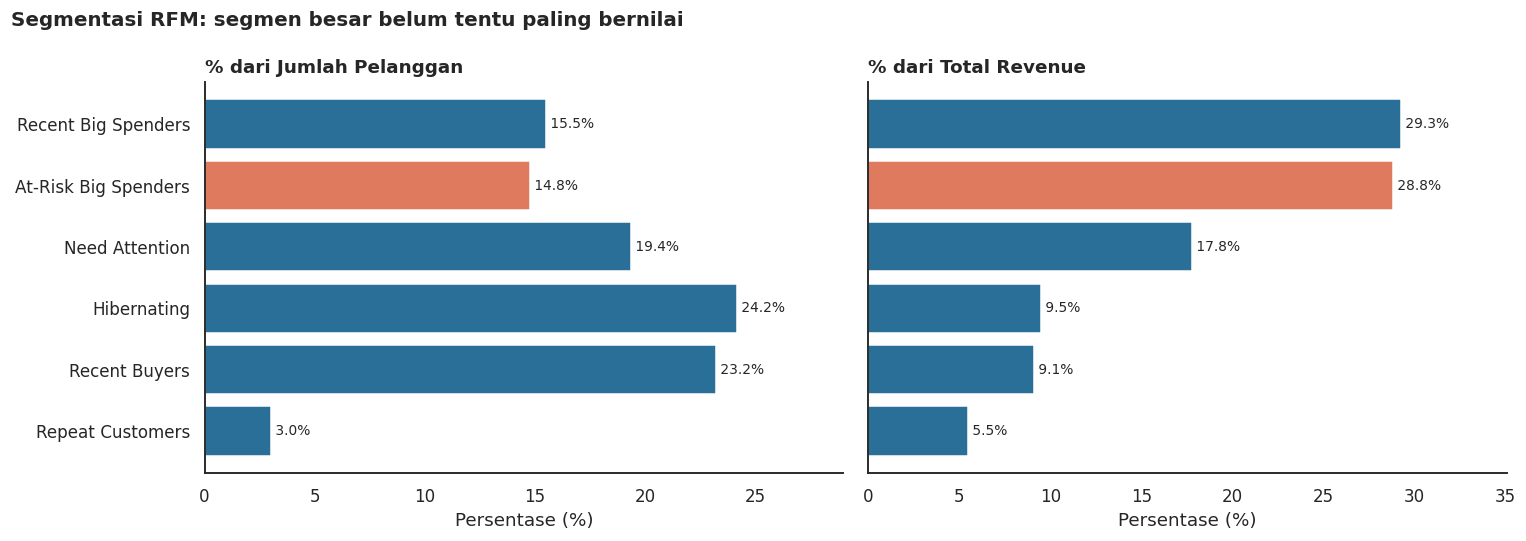

In [40]:
urut = segmen_df.sort_values("persen_revenue", ascending=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sorot = ["At-Risk Big Spenders"]
w = [ACCENT if s in sorot else PRIMARY for s in urut["segment"]]
for a, kol, judul, fmt in [(ax[0], "persen_pelanggan", "% dari Jumlah Pelanggan", "{:.1f}%"),
                           (ax[1], "persen_revenue", "% dari Total Revenue", "{:.1f}%")]:
    bars = a.barh(urut["segment"], urut[kol], color=w)
    a.set_title(judul, loc="left"); a.set_xlabel("Persentase (%)"); a.set_ylabel("")
    a.set_xlim(0, urut[kol].max() * 1.2)
    for b in bars:
        a.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(b.get_width()), va="center", fontsize=9)
fig.suptitle("Segmentasi RFM: segmen besar belum tentu paling bernilai", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

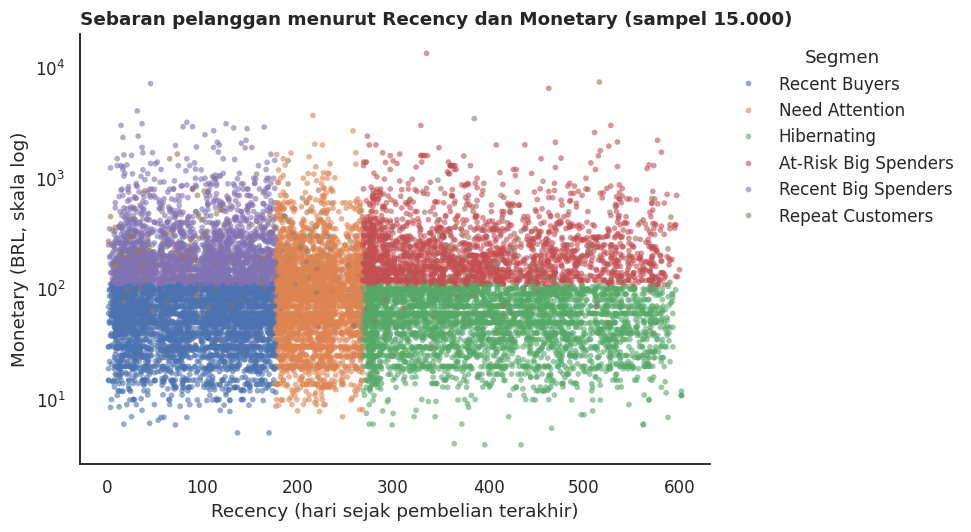

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = rfm_df.sample(15000, random_state=42)
sns.scatterplot(data=sample, x="recency", y="monetary", hue="segment", s=14, alpha=0.6, ax=ax, linewidth=0)
ax.set_yscale("log"); ax.set_xlabel("Recency (hari sejak pembelian terakhir)"); ax.set_ylabel("Monetary (BRL, skala log)")
ax.set_title("Sebaran pelanggan menurut Recency dan Monetary (sampel 15.000)", loc="left")
ax.legend(title="Segmen", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

**Insight Pertanyaan 4:**
- Hanya **3,0%** pelanggan (2.786 orang) yang pernah membeli lebih dari sekali (segmen *Repeat Customers*), dan segmen ini hanya menyumbang 5,5% revenue. Retensi pelanggan menjadi masalah utama.
- Dua segmen bernilai tinggi hampir seimbang: *Recent Big Spenders* (15,5% pelanggan, **29,3%** revenue; rata-rata recency 92 hari) dan *At-Risk Big Spenders* (14,8% pelanggan, **28,8%** revenue; rata-rata belanja R$ 276 tetapi rata-rata sudah 392 hari tidak membeli; 54% di antaranya lebih dari 365 hari).
- Segmen terbesar secara jumlah, *Hibernating* (24,2%) dan *Recent Buyers* (23,2%), masing-masing hanya menyumbang sekitar 9-10% revenue karena nilai belanjanya kecil (rata-rata R$ 56).
- Gabungan dua segmen *Big Spenders* hanya 30,3% pelanggan tetapi menghasilkan **58,1%** revenue.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Penjualan tumbuh pesat sepanjang 2017 (dari 749 pesanan pada Januari menjadi 4.478 pada Oktober) dan mencapai puncak pada **November 2017** dengan 7.288 pesanan dan revenue R$ 987.648, lalu stabil di kisaran 6.000 - 7.100 pesanan per bulan pada 2018. Pada periode Januari - Agustus, pesanan 2018 tumbuh 140% dan revenue 141% dibanding 2017, dengan nilai rata-rata pesanan stabil (R$ 124 - R$ 149). Artinya pertumbuhan berasal dari jumlah pesanan, dan puncak penjualan pada periode analisis terjadi pada November 2017.
- **Conclusion pertanyaan 2:** Lima kategori teratas berdasarkan revenue adalah `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`, dengan kontribusi gabungan **39,9%** revenue. Kategori terlaris dari sisi jumlah (`bed_bath_table`) berbeda dengan kategori dengan revenue tertinggi (`health_beauty`) karena perbedaan harga rata-rata; `watches_gifts` menghasilkan revenue besar dari volume yang lebih kecil.
- **Conclusion pertanyaan 3:** Pelanggan terkonsentrasi di SP, RJ, dan MG (66,5%), dengan SP sebagai pasar terbesar sekaligus yang pengirimannya tercepat (8,7 hari). Wilayah Timur Laut dan Utara (AL, PA, MA, SE, CE) memiliki waktu kirim 21 - 24 hari, sekitar 1,7 - 2,0 kali rata-rata nasional (12,5 hari). RJ dan BA adalah pasar besar dengan keterlambatan 13,5 - 14,1% dan skor review di bawah 4,0 (3,97 dan 3,93). Kepuasan pelanggan turun tajam begitu pengiriman melewati 21 hari (skor 3,61 pada 22-30 hari dan 2,24 pada >30 hari), serta pesanan terlambat mendapat skor 2,57 dibanding 4,30.
- **Conclusion pertanyaan 4:** Hanya 3% pelanggan yang pernah membeli ulang. Dua segmen bernilai tinggi (*Recent Big Spenders* dan *At-Risk Big Spenders*) mewakili 30,3% pelanggan tetapi 58,1% revenue. *At-Risk Big Spenders* berjumlah 13.745 pelanggan dengan rata-rata recency 392 hari; sekitar 54% di antaranya sudah lebih dari satu tahun tidak bertransaksi.

**Rekomendasi Action Item:**
- **Siapkan stok, kapasitas gudang, dan promosi menjelang November.** Mulai persiapan sejak Oktober untuk mengantisipasi volume permintaan yang serupa dengan puncak November 2017 (7.288 pesanan), serta siapkan strategi pemulihan setelahnya karena Desember turun sekitar 24%.
- **Prioritaskan lima kategori unggulan.** Jaga ketersediaan stok `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`. Untuk `bed_bath_table`, telusuri penyebab skor review terendah (3,92) karena volumenya paling besar. Evaluasi kategori yang hampir tidak terjual (kurang dari 10 item) untuk dipertahankan atau dihentikan.
- **Perbaiki logistik di wilayah lambat.** Evaluasi mitra kurir dan pertimbangkan gudang atau pusat distribusi regional untuk Timur Laut dan Utara (AL, PA, MA, SE, CE, BA), serta tinjau estimasi pengiriman agar lebih realistis. Pantau pesanan yang berisiko melewati 21 hari dan beri notifikasi proaktif atau kompensasi, karena di atas ambang itu kepuasan turun tajam.
- **Jalankan kampanye retensi berbasis segmen.** Beri penawaran *win-back* (voucher atau gratis ongkir) untuk *At-Risk Big Spenders*, program *second purchase* untuk *Recent Big Spenders* dan *Recent Buyers* agar menjadi pelanggan berulang, serta biaya rendah (email atau notifikasi) untuk *Hibernating*.